## 1 - PREPARAÇÃO DOS DADOS

1.1 - Importando Bibliotecas

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

1.2 - Extração de Arquivos Tratado

In [20]:
df = pd.read_csv('//content/Dados_Clientes_Telecom.csv')
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [21]:
df.columns

Index(['CustomerID', 'Churn', 'Gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'Tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesDaily', 'ChargesMonthly',
       'ChargesTotal'],
      dtype='object')

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


1.3 - Remoção de Colunas Irrelevantes

In [23]:
df = df.drop(columns=['CustomerID'], errors='ignore')
df

,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,No,Female,No,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.60,593.30
1,No,Male,No,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.90,542.40
2,Yes,Male,No,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.90,280.85
3,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.00,1237.85
4,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,No,Female,No,No,No,13,Yes,No,DSL,Yes,...,No,Yes,No,No,One year,No,Mailed check,1.84,55.15,742.90
7039,Yes,Male,No,Yes,No,22,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,2.84,85.10,1873.70
7040,No,Male,No,No,No,2,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,1.68,50.30,92.75
7041,No,Male,No,Yes,Yes,67,Yes,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,No,Mailed check,2.26,67.85,4627.65


1.4 - Encoding

In [24]:
# Agrupamento de categorias redundates
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace('No internet service', 'No')

In [25]:
# Transformar as categorias em números (One-Hot Encoding)
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()
if 'Churn' in colunas_categoricas: colunas_categoricas.remove('Churn')

df = pd.get_dummies(df, columns=colunas_categoricas)

print(f"Variáveis transformadas. Total de colunas: {df.shape[1]}")

Variáveis transformadas. Total de colunas: 41


In [26]:
# Mapeamento da variável alvo
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print("Variável 'Churn' convertida para binário.")
df.head()


Variável 'Churn' convertida para binário.


,Churn,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,Gender_Female,Gender_Male,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,2.19,65.6,593.30,True,False,True,False,False,...,False,False,True,False,False,True,False,False,False,True
1,0,9,2.00,59.9,542.40,False,True,True,False,True,...,True,True,False,False,True,False,False,False,False,True
2,1,4,2.46,73.9,280.85,False,True,True,False,True,...,False,True,False,False,False,True,False,False,True,False
3,1,13,3.27,98.0,1237.85,False,True,False,True,False,...,True,True,False,False,False,True,False,False,True,False
4,1,3,2.80,83.9,267.40,True,False,False,True,False,...,False,True,False,False,False,True,False,False,False,True


1.5 - Verificação da Proporção de Evasão

Proporção das Classes no Churn:
Categoria 0: 73.46%
Categoria 1: 26.54%


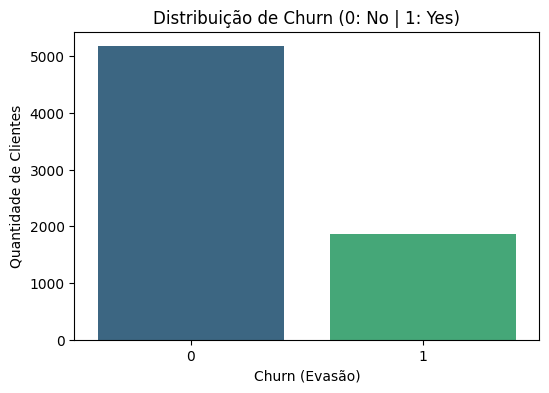

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Comando para esconder os avisos (warnings)
warnings.filterwarnings('ignore')

# Cálculo da proporção
proporcao = df['Churn'].value_counts(normalize=True) * 100

print("Proporção das Classes no Churn:")
for categoria, valor in proporcao.items():
    print(f"Categoria {categoria}: {valor:.2f}%")


# Gráfico:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribuição de Churn (0: No | 1: Yes)')
plt.ylabel('Quantidade de Clientes')
plt.xlabel('Churn (Evasão)')
plt.show()

1.6 - Balanceamento de Classes (SMOTE)

In [28]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Separando os preditores (X) da variável alvo (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Configurando o SMOTE
smt = SMOTE(random_state=42)

# Aplicando o balanceamento (criando os dados sintéticos)
X_res, y_res = smt.fit_resample(X, y)

# Criando um novo DataFrame com os dados equilibrados
df_balanced = pd.concat([X_res, y_res], axis=1)

print("Passo 1e (Balanceamento) concluído!")
print("-" * 30)
print("Nova proporção das classes no Churn:")
print(df_balanced['Churn'].value_counts(normalize=True) * 100)
print("-" * 30)
print(f"Total de registros ANTES: {df.shape[0]}")
print(f"Total de registros AGORA: {df_balanced.shape[0]}")

Passo 1e (Balanceamento) concluído!
------------------------------
Nova proporção das classes no Churn:
Churn
0    50.0
1    50.0
Name: proportion, dtype: float64
------------------------------
Total de registros ANTES: 7043
Total de registros AGORA: 10348


1.7 - Normalização

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Normalizador
scaler = MinMaxScaler()
df_final = pd.DataFrame(scaler.fit_transform(df_balanced), columns=df_balanced.columns)

print("Parte 1 - Preparação dos Dados, Concluída")
print("-" * 40)
print("Amostra dos dados normalizados:")

# Mostrando apenas algumas colunas para conferência
display(df_final[['Tenure', 'ChargesMonthly']].head())

Parte 1 - Preparação dos Dados, Concluída
----------------------------------------
Amostra dos dados normalizados:


,Tenure,ChargesMonthly
0,0.125000,0.471144
1,0.125000,0.414428
2,0.055556,0.553731
3,0.180556,0.793532
4,0.041667,0.653234


## 2 - CORRELAÇÃO E SELEÇÃO DE VARIAVEIS

2.1 - Análise de Correlação

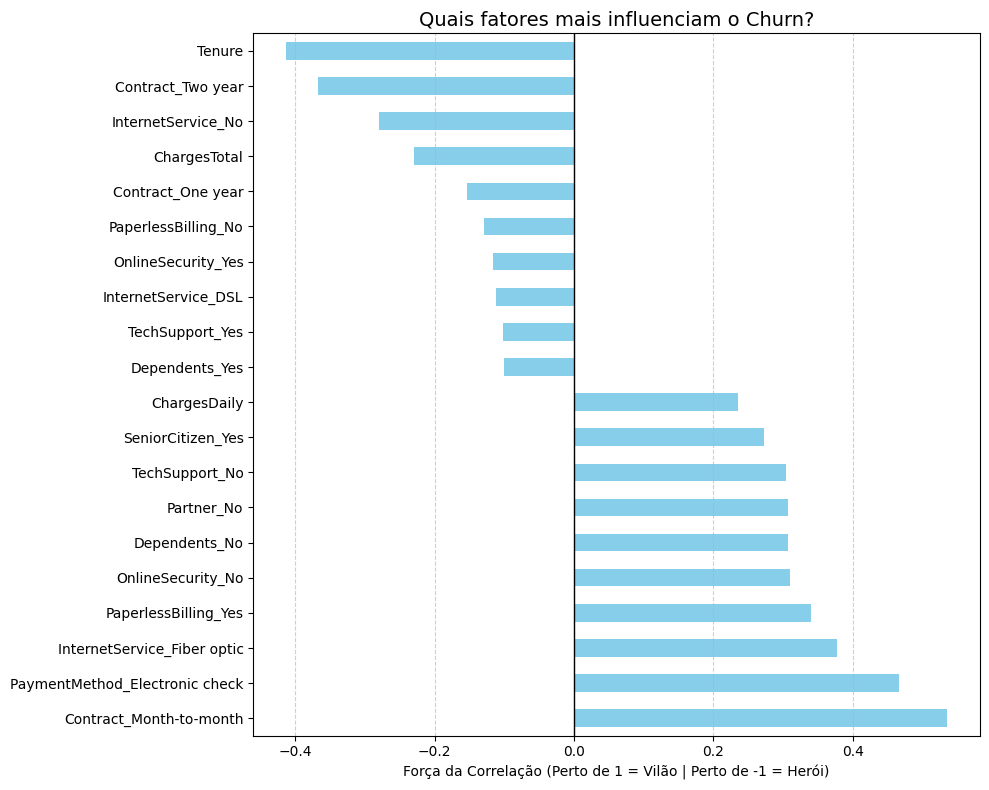


 VILÕES (Quanto MAIOR esse fator, MAIOR o Churn):
Contract_Month-to-month           0.535272
PaymentMethod_Electronic check    0.466631
InternetService_Fiber optic       0.378072
PaperlessBilling_Yes              0.340571
OnlineSecurity_No                 0.309464
Name: Churn, dtype: float64

 HERÓIS (Quanto MAIOR esse fator, MENOR o Churn):
Contract_One year    -0.153005
ChargesTotal         -0.230036
InternetService_No   -0.280288
Contract_Two year    -0.367156
Tenure               -0.413099
Name: Churn, dtype: float64


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculando a correlação de todas as variáveis com a nossa variável alvo 'Churn'
correlacao = df_final.corr()['Churn'].sort_values(ascending=False)

# Criando um gráfico horizontal para facilitar a leitura dos vilões e heróis
plt.figure(figsize=(10, 8))

# Vamos pegar os 10 maiores influenciadores positivos e os 10 negativos
top_correlacoes = pd.concat([correlacao.head(11), correlacao.tail(10)])
top_correlacoes.drop('Churn', errors='ignore').plot(kind='barh', color='skyblue')

plt.title('Quais fatores mais influenciam o Churn?', fontsize=14)
plt.xlabel('Força da Correlação (Perto de 1 = Vilão | Perto de -1 = Herói)')
plt.axvline(0, color='black', lw=1) # Linha central para separar os lados
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Resumo Executivo
print("\n VILÕES (Quanto MAIOR esse fator, MAIOR o Churn):")
print(correlacao[1:6]) # Do 1º ao 5º maior (pulando o próprio Churn)

print("\n HERÓIS (Quanto MAIOR esse fator, MENOR o Churn):")
print(correlacao.tail(5))

2.2 - Análise Direcionada

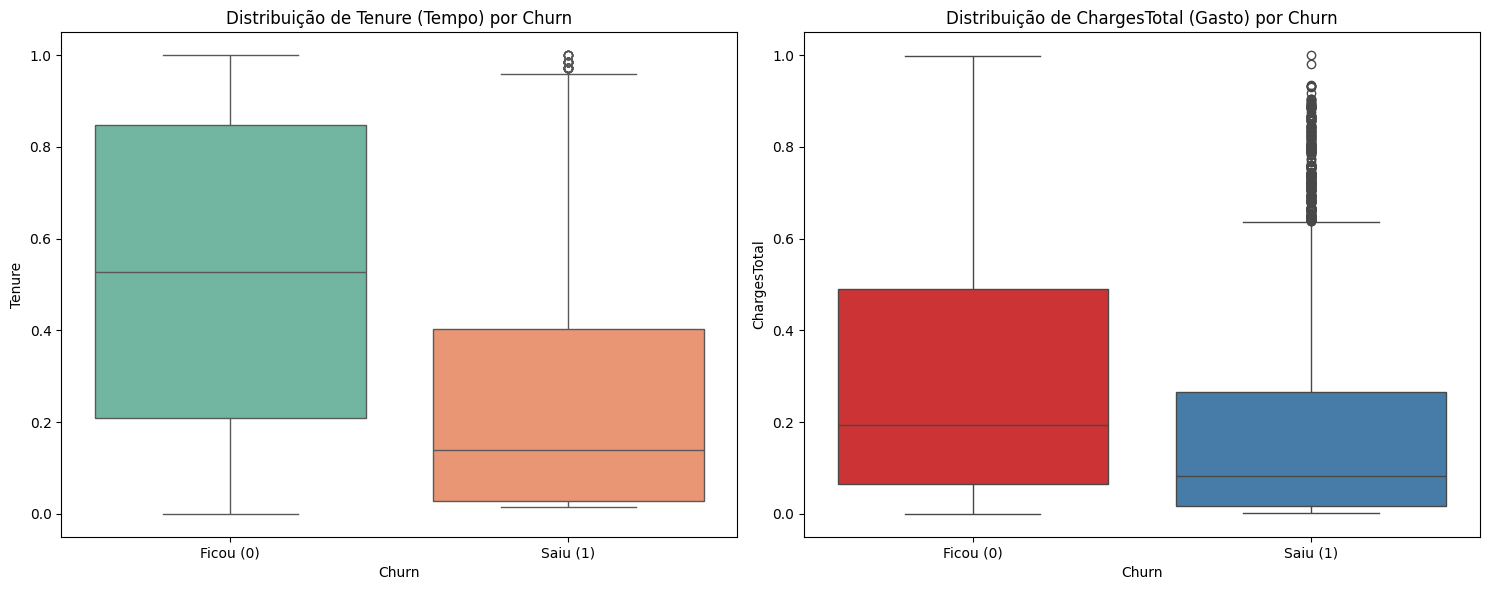

In [32]:
# Criando a área do gráfico
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Investigação: Tempo de Contrato (Tenure) x Evasão (Se quem sai, realmente sai cedo)
sns.boxplot(x='Churn', y='Tenure', data=df_final, ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição de Tenure (Tempo) por Churn', fontsize=12)
axes[0].set_xticklabels(['Ficou (0)', 'Saiu (1)'])

# Investigação: Total Gasto (ChargesTotal) x Evasão (Se dinheiro gasto, influência na permanência)
sns.boxplot(x='Churn', y='ChargesTotal', data=df_final, ax=axes[1], palette='Set1')
axes[1].set_title('Distribuição de ChargesTotal (Gasto) por Churn', fontsize=12)
axes[1].set_xticklabels(['Ficou (0)', 'Saiu (1)'])

plt.tight_layout()
plt.show()